# Import Statements

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf

from modules.utils import *
from modules.screen import *
from modules.data_loader import *
from modules.portfolio import *
from modules.trade import *
from modules.backtest import *
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

---
# Parameters

In [2]:
config = load_config("config.yaml")

start_date = config["start_date"]
end_date = config["end_date"]
BENCHMARK = config["benchmark"]
UPDATE = config["update"]
SCREEN = config["screen"]

---
# Data Fetching

In [3]:
# Loading data for all NSE tickers and calculating features
full_nse_tickers = load_nse_all()
load_full_data = load_data(start_date=start_date, end_date=end_date, update=UPDATE, full_nse_tickers=full_nse_tickers)

---
# Backtest - Simulation

In [4]:
backtest_df, trade_blotter = run_backtest(
    price_df=load_full_data,
    screen_rule=SCREEN,
    initial_cash=config["cash"],
    rebalance_freq=config["rebalance_frequency"],
    feature_df=load_full_data,
    start_date=start_date,    
    end_date=end_date,
    allocator="max_sharpe",
    ranker_dict=config["ranker"]
)


📅 Progress: 0/1546 | Date: 2020-01-01

📅 Progress: 10/1546 | Date: 2020-01-15

📅 Progress: 20/1546 | Date: 2020-01-29

🔁 Rebalance triggered on 2020-01-31
   💰 Portfolio value: 1,000,000.00
   🧾 Cash: 1,000,000.00
   🎯 Screened stocks: 100
   📊 Ranked stocks: 10
   🧠 Top allocations: [('BBOX.NS', 0.62795), ('EPL.NS', 0.13884), ('ALKYLAMINE.NS', 0.0868), ('RELAXO.NS', 0.06622), ('IGL.NS', 0.04987)]
   💼 Trades executed | New cash: 367.85

📅 Progress: 30/1546 | Date: 2020-02-12

📅 Progress: 40/1546 | Date: 2020-02-27

🔁 Rebalance triggered on 2020-02-28
   💰 Portfolio value: 1,474,208.04
   🧾 Cash: 367.85
   🎯 Screened stocks: 62
   📊 Ranked stocks: 10
   🧠 Top allocations: [('BBOX.NS', 0.65733), ('ATUL.NS', 0.24601), ('DIVISLAB.NS', 0.04924), ('ALKYLAMINE.NS', 0.03567), ('JBCHEPHARM.NS', 0.01175)]
   💼 Trades executed | New cash: 3,996.58

📅 Progress: 50/1546 | Date: 2020-03-13

📅 Progress: 60/1546 | Date: 2020-03-27

🔁 Rebalance triggered on 2020-03-31
   💰 Portfolio value: 929,637.43

# Portfolio Analysis

<Axes: title={'center': 'Equity Curve'}, xlabel='Date'>

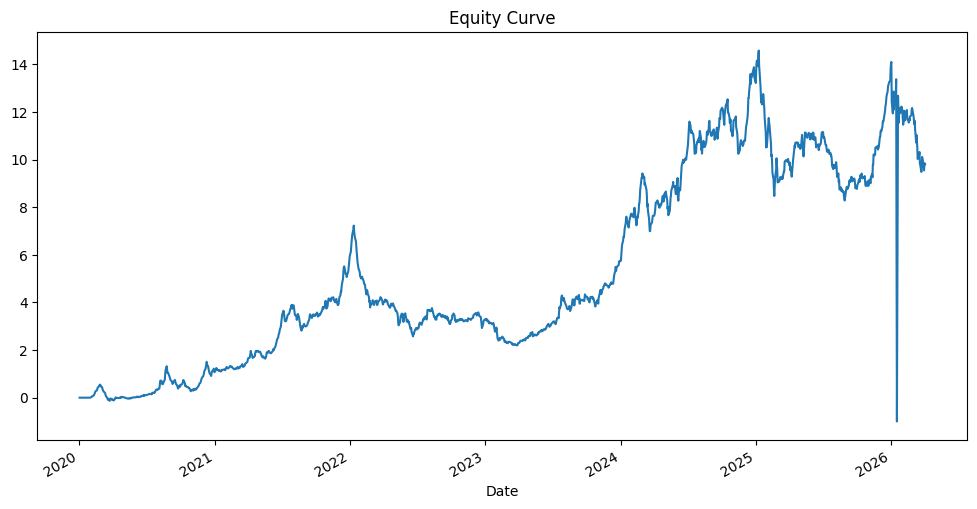

In [17]:
((1 + backtest_df.set_index('Date')['equity'].pct_change()).cumprod() - 1).plot(title="Equity Curve", figsize=(12, 6))